# HW01 作业
姓名：黄大康
学号：20234080423
日期：2026.04.22

## 2.1 线性代数理论题

1. 向量点积 a·b = 2×1 + (-1)×4 + 3×(-2) = **-8**

2. 矩阵乘法 A×B 形状：2×2

$$
A\times B=
\begin{bmatrix}
8 & 5 \\
1 & -2
\end{bmatrix}
$$

3. a 的 Frobenius 范数：
$$
\|a\|_F=\sqrt{2^2+(-1)^2+3^2}=\sqrt{14}\approx3.7417
$$

## 2.2 线性代数编程

In [28]:
import numpy as np

# 1. 3×4 标准正态随机矩阵 X
X = np.random.randn(3, 4)

# 2. 4×2 全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y

# 4. 输出指定位置
print("Z[0,1] =", Z[0, 1])
print("Z 第2行 =", Z[1, :])

# 5. Frobenius 范数
print("||Z||_F =", np.linalg.norm(Z))

Z[0,1] = 1.7366827117133712
Z 第2行 = [2.62207372 2.62207372]
||Z||_F = 5.2932865555256114


## 3.1 贝叶斯公式

患病率 0.1%，灵敏度 99%，假阳性 2%

$$
P(A|B) = \frac{0.99\times0.001}{0.99\times0.001 + 0.02\times0.999}\approx 4.72\%
$$

## 3.2 中心极限定理模拟

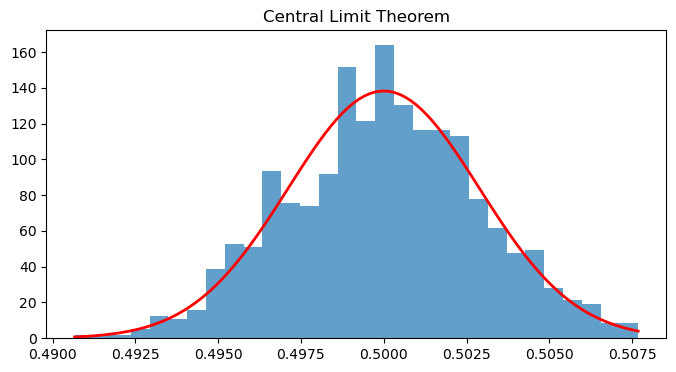

实际方差 = 8.44451973101189e-06


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n = 10000
m = 1000
means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

plt.figure(figsize=(8, 4))
plt.hist(means, bins=30, density=True, alpha=0.7)
mu, sigma = 0.5, np.sqrt(1 / (12 * n))
x = np.linspace(min(means), max(means), 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2)
plt.title('Central Limit Theorem')
plt.show()

print("实际方差 =", np.var(means))

## 4.1 导数与梯度

z = (2w₁ + w₂ − 3)²

1. 梯度：
$$
\frac{\partial z}{\partial w_1}=4(2w_1+w_2-3),\quad
\frac{\partial z}{\partial w_2}=2(2w_1+w_2-3)
$$

2. w₁=0.5, w₂=1：
$$
\nabla z = (-4, -2)
$$

## 4.2 手动反向传播

In [30]:
import torch

x, w1, w2 = 2, 1.5, 0.5

# 前向
a = x * w1
b = a + w2
L = b ** 2
print("前向 L =", L)

# 手动梯度
dL_dw1 = 2 * b * x
dL_dw2 = 2 * b
print("手动 dw1 =", dL_dw1)
print("手动 dw2 =", dL_dw2)

# 自动微分验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
L_t = (2 * w1_t + w2_t) ** 2
L_t.backward()
print("自动 dw1 =", w1_t.grad.item())
print("自动 dw2 =", w2_t.grad.item())

前向 L = 12.25
手动 dw1 = 14.0
手动 dw2 = 7.0
自动 dw1 = 14.0
自动 dw2 = 7.0


## 5.1 线性回归梯度

$$
\frac{\partial L}{\partial w} = -\frac{2}{n}\sum x_i(y_i - wx_i -b)
$$

$$
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum (y_i - wx_i -b)
$$

## 5.2 Softmax 回归（MNIST）

In [31]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

data = load_digits()
X = data.data / 16.0
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def one_hot(y, n_class=10):
    return np.eye(n_class)[y]

y_train_one = one_hot(y_train)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

W = np.zeros((64, 10))
b = np.zeros(10)
lr = 0.1
epochs = 50
batch_size = 32

for epoch in range(epochs):
    for i in range(0, len(X_train), batch_size):
        Xb = X_train[i:i+batch_size]
        yb = y_train_one[i:i+batch_size]
        logits = Xb @ W + b
        pred = softmax(logits)
        dW = Xb.T @ (pred - yb) / len(Xb)
        db = np.mean(pred - yb, axis=0)
        W -= lr * dW
        b -= lr * db

pred_test = softmax(X_test @ W + b)
acc = np.mean(np.argmax(pred_test, axis=1) == y_test)
print("测试集准确率 =", acc)

测试集准确率 = 0.9611111111111111


## 6.1 最大似然估计

1. 似然函数：
$$
L(\mu,\sigma^2)=\prod_{i=1}^n\frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x_i-\mu)^2}{2\sigma^2}}
$$

2. $\hat\mu = \frac1n\sum x_i$

3. $\hat\sigma^2 = \frac1n\sum(x_i-\hat\mu)^2$

## 6.2 逻辑回归

测试准确率 = 0.95


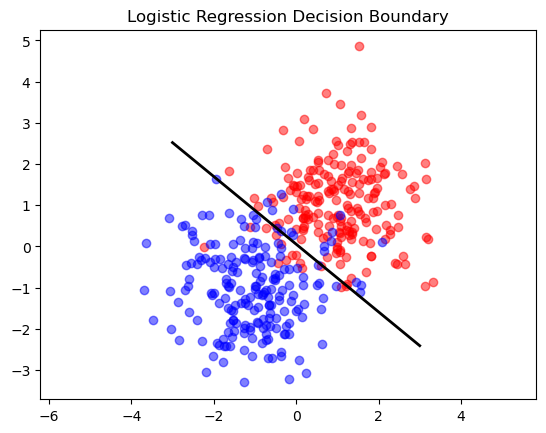

In [32]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
X0 = np.random.randn(200, 2) + np.array([1, 1])
X1 = np.random.randn(200, 2) + np.array([-1, -1])
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(200), np.ones(200)])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

w = np.zeros(2)
b = 0.0
lr = 0.1
iters = 1000

for _ in range(iters):
    z = X @ w + b
    pred = sigmoid(z)
    dw = X.T @ (pred - y) / len(y)
    db = np.mean(pred - y)
    w -= lr * dw
    b -= lr * db

# 测试
X_test0 = np.random.randn(50, 2) + [1, 1]
X_test1 = np.random.randn(50, 2) + [-1, -1]
X_test = np.vstack([X_test0, X_test1])
y_test = np.hstack([np.zeros(50), np.ones(50)])
pred_test = (sigmoid(X_test @ w + b) > 0.5).astype(int)
acc = np.mean(pred_test == y_test)
print("测试准确率 =", acc)

# 绘图
plt.scatter(X0[:,0], X0[:,1], c='r', alpha=0.5)
plt.scatter(X1[:,0], X1[:,1], c='b', alpha=0.5)
x_line = np.linspace(-3, 3, 100)
y_line = -(w[0] * x_line + b) / w[1]
plt.plot(x_line, y_line, 'k-', lw=2)
plt.title('Logistic Regression Decision Boundary')
plt.axis('equal')
plt.show()